# Financial fraud analysis: Finding patterns

In [68]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import time

np.random.seed(42)

## About Dataset

This dataset contains 10,000 synthetic financial transactions designed for fraud detection research and model development. It simulates realistic user behavior and fraudulent patterns to provide a safe environment for testing machine learning models without exposing any real sensitive data.

### Key features include:

transaction_id: Unique identifier for each transaction

user_id: Identifier for the user performing the transaction

amount: Transaction amount (in local currency)

transaction_type: Type of transaction (POS, Online, ATM, QR)

merchant_category: Category of the merchant

country: Country where the transaction took place

hour: Hour of the transaction (0–23)

device_risk_score and ip_risk_score: Risk indicators for the device and IP

is_fraud: Label indicating if the transaction is fraudulent (1) or legitimate (0)

### Fraud patterns simulated include:

* Transactions with unusually high amounts
* Transactions in unusual countries for the user
* Night-time transactions
* Rapid multiple transactions
* Transactions from newly created accounts
* High-risk devices or IP addresses

### This dataset is ideal for:

* Training and testing fraud detection models
* Exploratory data analysis (EDA) of transaction behaviors
* Benchmarking anomaly detection algorithms

## Examining the data

In [17]:
df = pd.read_csv("data/synthetic_fraud_dataset.csv")
print(df.columns.values)
df.head()

['transaction_id' 'user_id' 'amount' 'transaction_type'
 'merchant_category' 'country' 'hour' 'device_risk_score' 'ip_risk_score'
 'is_fraud']


,transaction_id,user_id,amount,transaction_type,merchant_category,country,hour,device_risk_score,ip_risk_score,is_fraud
0,9608,363,4922.587542,ATM,Travel,TR,12,0.992347,0.947908,1
1,456,692,48.018303,QR,Food,US,21,0.168571,0.224057,0
2,4747,587,136.881960,Online,Travel,TR,14,0.296127,0.125058,0
3,6934,445,80.534719,POS,Clothing,TR,23,0.124801,0.159243,0
4,1646,729,120.041158,Online,Grocery,FR,16,0.098129,0.027542,0


In [30]:
# Missing values or duplicates?
print("Missing values:\n" + str(df.isna().sum()))
print("\nDuplicated entries: ", df.duplicated().sum())

Missing values:
transaction_id       0
user_id              0
amount               0
transaction_type     0
merchant_category    0
country              0
hour                 0
device_risk_score    0
ip_risk_score        0
is_fraud             0
dtype: int64

Duplicated entries:  0


In [3]:
# How many transactions were fraudulent?
print("Number of fraudulent transactions:", df['is_fraud'].value_counts())

Number of fraudulent transactions: is_fraud
0    9500
1     500
Name: count, dtype: int64


In [32]:
# Descriptive stats
df[["amount", "hour", "device_risk_score", "ip_risk_score", "is_fraud"]].describe().T

,count,mean,std,min,25%,50%,75%,max
amount,10000.0,178.142763,531.647950,1.000000,65.084753,101.686510,138.280872,11628.213881
hour,10000.0,14.247100,5.347383,0.000000,10.000000,14.000000,19.000000,23.000000
device_risk_score,10000.0,0.183773,0.177381,0.000030,0.075721,0.156583,0.234939,0.998737
ip_risk_score,10000.0,0.184669,0.175772,0.000009,0.077762,0.158290,0.236968,0.999603
is_fraud,10000.0,0.050000,0.217956,0.000000,0.000000,0.000000,0.000000,1.000000


In [33]:
# What is the mean amount of money stolen?
df.groupby("is_fraud")[["amount", "hour", "device_risk_score", "ip_risk_score"]].mean()

,amount,hour,device_risk_score,ip_risk_score
is_fraud,,,,
0,100.277751,14.469684,0.148290,0.149558
1,1657.577984,10.018000,0.857951,0.851770


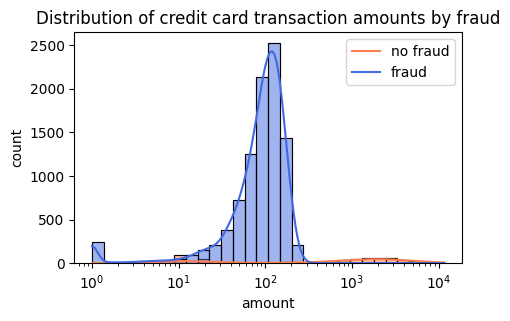

In [13]:
# Examine the distribution of the credit card transaction amounts by fraud
plt.figure(figsize = (5, 3))
sns.histplot(data=df, x="amount", hue="is_fraud", log_scale=True, bins=30, palette=["royalblue", "coral"], kde=True)
plt.title("Distribution of credit card transaction amounts by fraud")
plt.xlabel("amount")
plt.ylabel("count")
plt.legend(["no fraud", "fraud"])
plt.show()

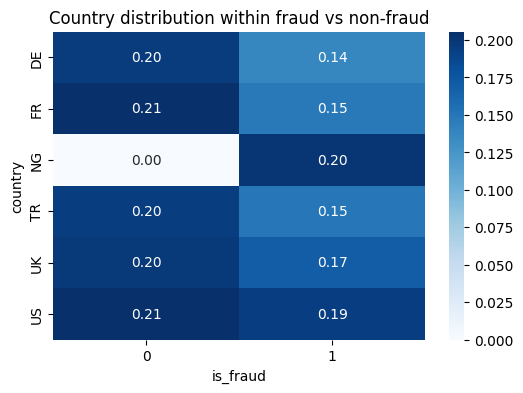

In [14]:
# What is the distribution of fraudulent and non-fraudulent movements per country?
prop = pd.crosstab(df["country"], df["is_fraud"], normalize="columns")
plt.figure(figsize=(6,4))
sns.heatmap(prop, annot=True, fmt=".2f", cmap="Blues")
plt.title("Country distribution within fraud vs non-fraud")
plt.xlabel("is_fraud")
plt.ylabel("country")
plt.show()

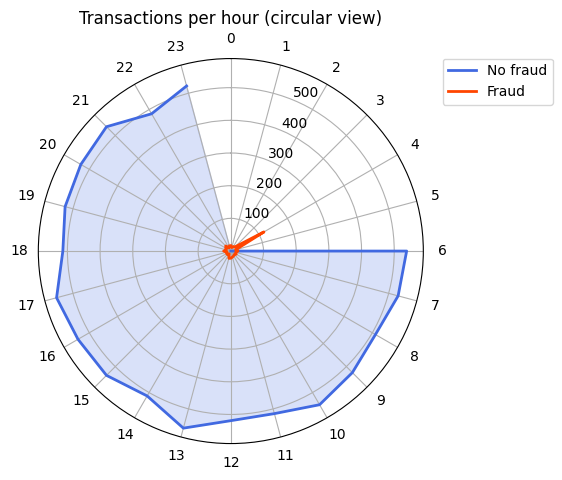

In [8]:
# Examine the transactions per hour
counts = (df.groupby(["hour","is_fraud"]).size().reset_index(name="count"))
counts = counts.pivot(index="hour", columns="is_fraud", values="count").fillna(0)

angles = np.linspace(0, 2*np.pi, 24, endpoint=False)

fig, ax = plt.subplots(figsize=(5,5), subplot_kw={"projection":"polar"})
ax.plot(angles, counts[0], label="No fraud", color="royalblue", linewidth=2)
ax.plot(angles, counts[1], label="Fraud", color="orangered", linewidth=2)
ax.fill(angles, counts[0], alpha=0.2, color="royalblue")
ax.fill(angles, counts[1], alpha=0.2, color="orangered")
ax.set_theta_zero_location("N") # midnight at top
ax.set_theta_direction(-1) # clockwise
ax.set_xticks(angles)
ax.set_xticklabels(range(24))
ax.set_title("Transactions per hour (circular view)")
ax.legend(loc="upper left", bbox_to_anchor=(1.05, 1), borderaxespad=0, frameon=True)

plt.show()

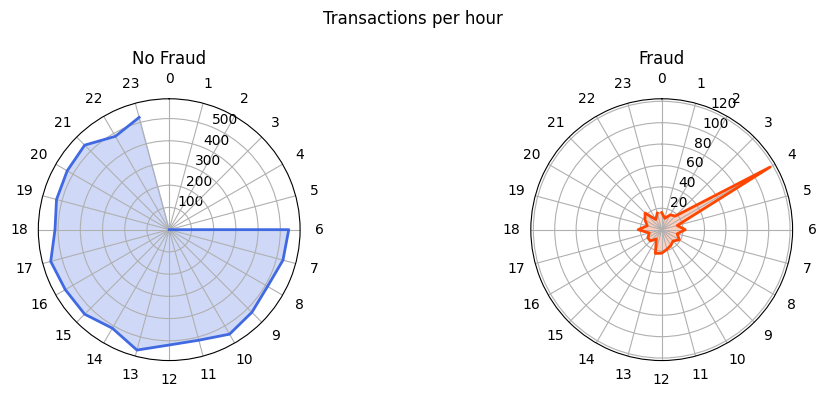

In [9]:
# A closer view
fig, axes = plt.subplots(1, 2, figsize=(10,4), subplot_kw={"projection":"polar"})

fraud_labels = {0: "No Fraud", 1: "Fraud"}
colors = {0: "royalblue", 1: "orangered"}

for i, fraud in enumerate([0,1]):
    ax = axes[i]
    ax.plot(angles, counts[fraud], color=colors[fraud], linewidth=2)
    ax.fill(angles, counts[fraud], color=colors[fraud], alpha=0.25)
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_xticks(angles)
    ax.set_xticklabels(range(24))
    ax.set_title(fraud_labels[fraud])
plt.suptitle("Transactions per hour")
plt.tight_layout()
plt.show()

## Preparing data for training

In [38]:
features = ['amount', 'hour', 'device_risk_score', 'ip_risk_score']
X = df[features]
y = df['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Random forest

In [47]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1900
           1       1.00      1.00      1.00       100

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

AUC = 1.0


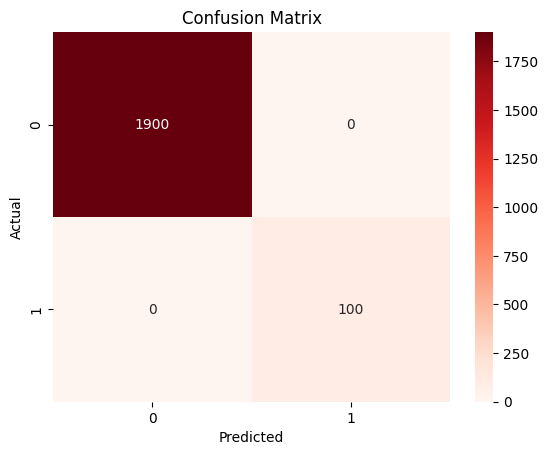

In [67]:
y_pred = rf_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Predict probabilities of the positive class (i.e., fraud)
y_prob = rf_model.predict_proba(X_test)[:, 1]
print("AUC =", roc_auc_score(y_test, y_prob))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Importance:
device_risk_score    0.454575
ip_risk_score        0.433121
amount               0.112076
hour                 0.000228
dtype: float64
Elapsed time to calculate feature importances: 0.026 seconds


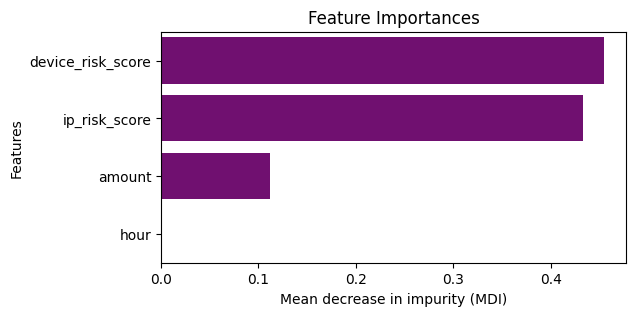

In [80]:
# Feature importance
start_time = time.time()
importance = pd.Series(rf_model.feature_importances_, index=X.columns)
print("Importance:\n" + str(importance.sort_values(ascending=False)))

importances = rf_model.feature_importances_
std = np.std([tree.feature_importances_ for tree in rf_model.estimators_], axis=0)
elapsed_time = time.time() - start_time
print(f"Elapsed time to calculate feature importances: {elapsed_time:.3f} seconds")

sorted_idx = np.argsort(importances)[::-1]
plt.figure(figsize=(6, 3))
sns.barplot(x=importances[sorted_idx], y=np.array(features)[sorted_idx], orient='h', color="purple")
plt.xlabel("Mean decrease in impurity (MDI)")
plt.ylabel("Features")
plt.title("Feature Importances")
plt.show()